Extract data from netCDF files and plot

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

In [15]:
# Create array of rotations
rot_earth = 7.2921159e-5
rot_rate = np.arange(0.1,2.1,0.1)
print(rot_rate)

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2. ]


<>:33: SyntaxWarning: invalid escape sequence '\ '
<>:33: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_36916/2895524742.py:33: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel('Rotation rate \ $\Omega$ Earth')


66.5648854961832
61.60305343511451
68.85496183206106
63.58778625954199
69.54198473282443
49.274809160305345
55.41984732824427
54.656488549618324
54.045801526717554
54.42748091603053
54.541984732824424
54.38931297709924
54.770992366412216
55.343511450381676
55.38167938931298
55.38167938931298
55.80152671755725
56.33587786259542
56.10687022900763
56.18320610687023
[66.5648854961832, 61.60305343511451, 68.85496183206106, 63.58778625954199, 69.54198473282443, 49.274809160305345, 55.41984732824427, 54.656488549618324, 54.045801526717554, 54.42748091603053, 54.541984732824424, 54.38931297709924, 54.770992366412216, 55.343511450381676, 55.38167938931298, 55.38167938931298, 55.80152671755725, 56.33587786259542, 56.10687022900763, 56.18320610687023]


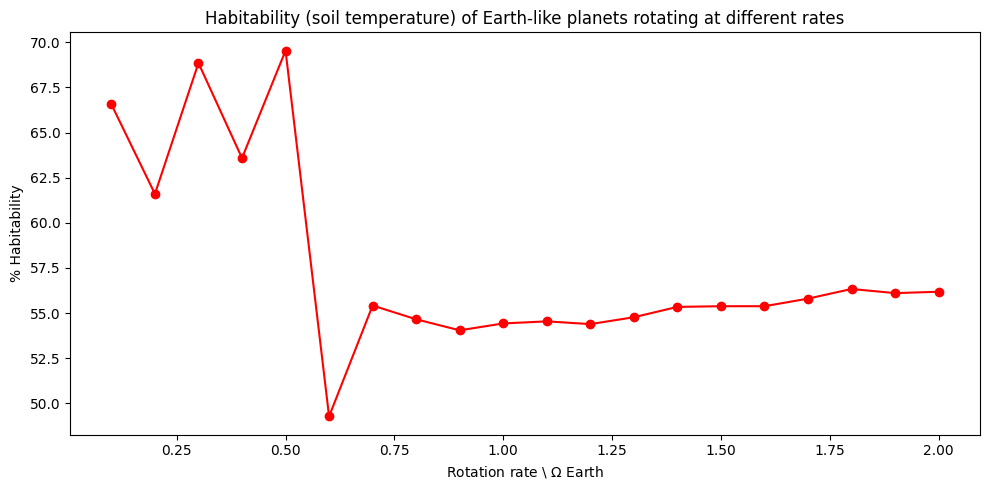

In [16]:
# Habitability fraction for surface soil temperature

hab_frac_st = []

for idx in range(1, 21):

    path = f"rotation_trials/output_rot_{idx}.nc"
    ds = xr.open_dataset(path)
    da = ds["st"].isel(soil_layer=0)

    # land mask: 
    # Only include values where soil moisture changes in time
    # land has time variability, ocean does not
    da_sm = ds["sm"].isel(soil_layer=0)
    land = da_sm.std(dim="time") > 0

    # time-mean
    da_mean = da.mean(dim="time")

    # fraction of land grid cells
    hab_fraction = ((da_mean >= 0) & (da_mean <= 48) & land).sum().item() / land.sum().item() * 100

    print(hab_fraction)
    hab_frac_st.append(hab_fraction)

print(hab_frac_st)

# Create the plot
fig = plt.figure(figsize=(10, 5))
plt.plot(rot_rate, hab_frac_st, marker='o', linestyle='-', color='r')

# Add labels and title
plt.xlabel('Rotation rate \ $\Omega$ Earth')
plt.ylabel('% Habitability')
plt.title('Habitability (soil temperature) of Earth-like planets rotating at different rates')
plt.tight_layout()
#plt.savefig("rot_sm.png")
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\ '
<>:25: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_36916/1320433678.py:25: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel('Rotation rate \ $\Omega$ Earth')


63.62847222222222
60.177951388888886
56.59722222222222
55.38194444444444
55.46875
51.45399305555556
50.998263888888886
50.1953125
50.0
50.30381944444444
49.8046875
49.39236111111111
49.4140625
49.13194444444444
48.84982638888889
48.84982638888889
48.67621527777778
48.30729166666667
47.67795138888889
47.69965277777778
[63.62847222222222, 60.177951388888886, 56.59722222222222, 55.38194444444444, 55.46875, 51.45399305555556, 50.998263888888886, 50.1953125, 50.0, 50.30381944444444, 49.8046875, 49.39236111111111, 49.4140625, 49.13194444444444, 48.84982638888889, 48.84982638888889, 48.67621527777778, 48.30729166666667, 47.67795138888889, 47.69965277777778]


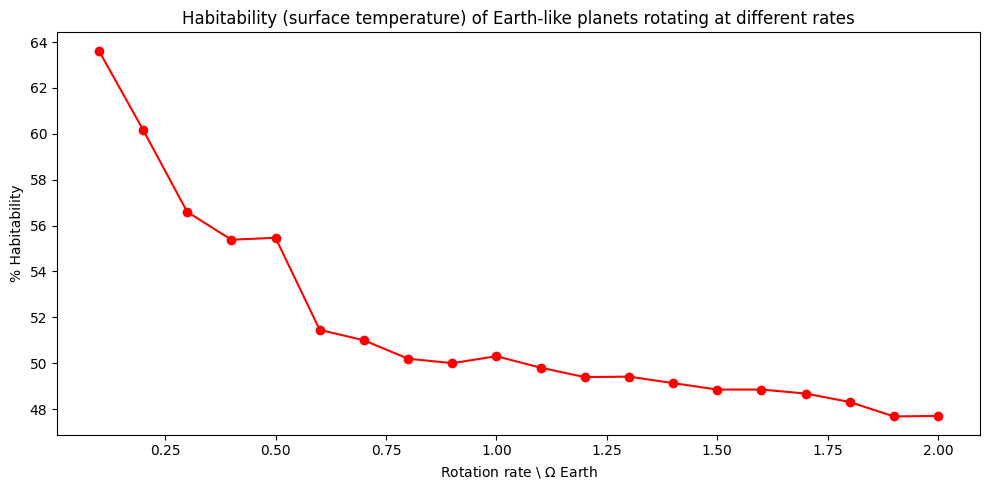

In [17]:
# Habitability fraction for surface air temperature

hab_frac_tsurf = []

for idx in range(1, 21):

    path = f"rotation_trials/output_rot_{idx}.nc"
    ds = xr.open_dataset(path)


    da_mean = ds["tsurf"].mean(dim="time")

    hab_tsurf = (da_mean >= 0) & (da_mean <= 48)
    hab_fraction_tsurf = hab_tsurf.mean().item() * 100
    print(hab_fraction_tsurf)
    hab_frac_tsurf.append(hab_fraction_tsurf)

print(hab_frac_tsurf)

# Create the plot
fig = plt.figure(figsize=(10, 5))
plt.plot(rot_rate, hab_frac_tsurf, marker='o', linestyle='-', color='r')

# Add labels and title
plt.xlabel('Rotation rate \ $\Omega$ Earth')
plt.ylabel('% Habitability')
plt.title('Habitability (surface temperature) of Earth-like planets rotating at different rates')
plt.tight_layout()
#plt.savefig("rot_tsurf.png")
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\ '
<>:34: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_36916/2394456931.py:34: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel('Rotation rate \ $\Omega$ Earth')


84.54198473282443
83.62595419847328
88.2442748091603
88.66412213740458
86.94656488549619
89.16030534351145
89.12213740458014
89.27480916030535
89.35114503816793
89.27480916030535
89.35114503816793
89.27480916030535
89.19847328244275
89.23664122137404
89.19847328244275
89.12213740458014
89.19847328244275
89.16030534351145
89.12213740458014
89.12213740458014
[84.54198473282443, 83.62595419847328, 88.2442748091603, 88.66412213740458, 86.94656488549619, 89.16030534351145, 89.12213740458014, 89.27480916030535, 89.35114503816793, 89.27480916030535, 89.35114503816793, 89.27480916030535, 89.19847328244275, 89.23664122137404, 89.19847328244275, 89.12213740458014, 89.19847328244275, 89.16030534351145, 89.12213740458014, 89.12213740458014]


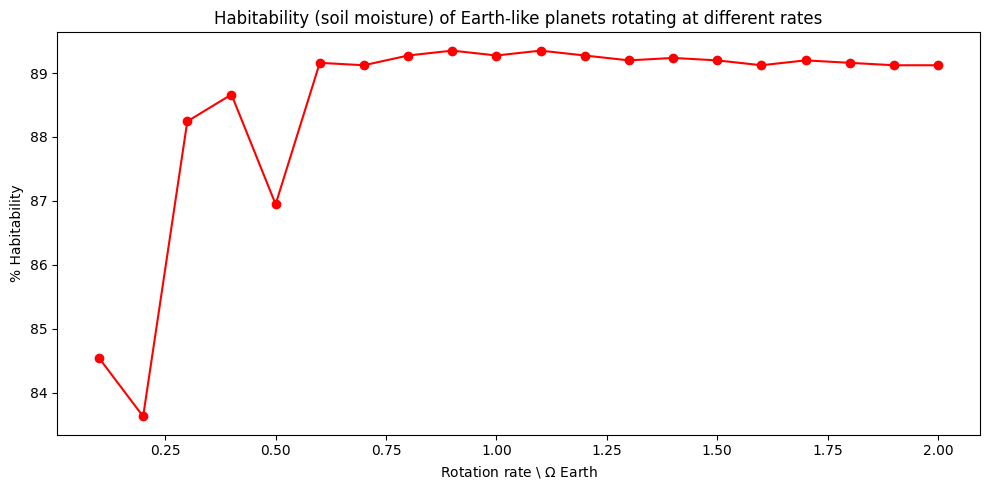

In [19]:
# Habitability fraction for surface soil moisture

hab_frac_sm = []

for idx in range(1, 21):

    path = f"rotation_trials/output_rot_{idx}.nc"
    ds = xr.open_dataset(path)

    # soil moisture at surface
    da = ds["sm"].isel(soil_layer=0)

    # land mask: 
    # Only include values of soil moisture that change in time
    # land has time variability, ocean does not
    land = da.std(dim="time") > 0

    # time-mean soil moisture
    da_mean = da.mean(dim="time")

    # fraction of land grid cells with mean SM >= 0.1
    hab_fraction = ((da_mean >= 0.1) & land).sum().item() / land.sum().item() * 100

    print(hab_fraction)
    hab_frac_sm.append(hab_fraction)

print(hab_frac_sm)

# Create the plot
fig = plt.figure(figsize=(10, 5))
plt.plot(rot_rate, hab_frac_sm, marker='o', linestyle='-', color='r')

# Add labels and title
plt.xlabel('Rotation rate \ $\Omega$ Earth')
plt.ylabel('% Habitability')
plt.title('Habitability (soil moisture) of Earth-like planets rotating at different rates')
plt.tight_layout()
#plt.savefig("rot_sm.png")
plt.show()

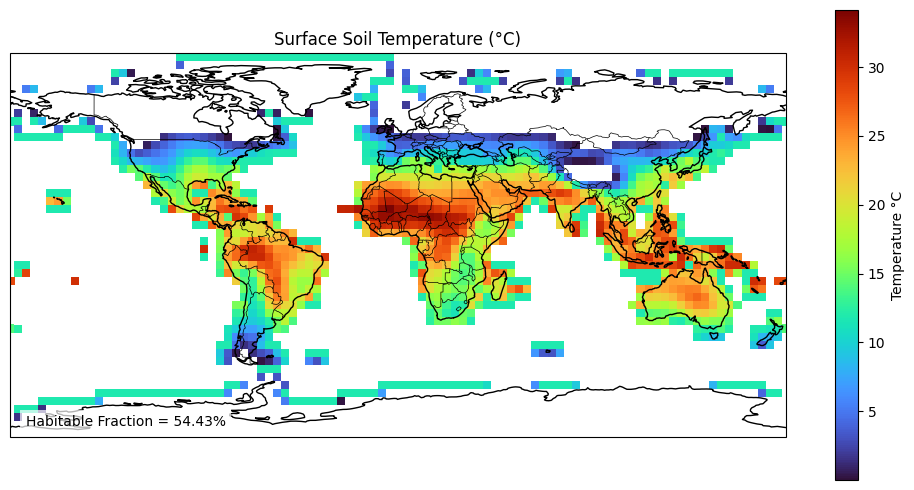

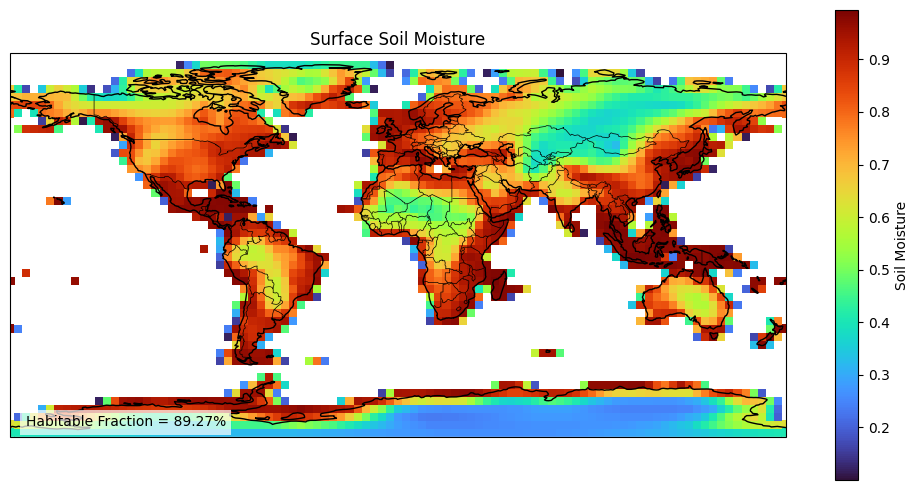

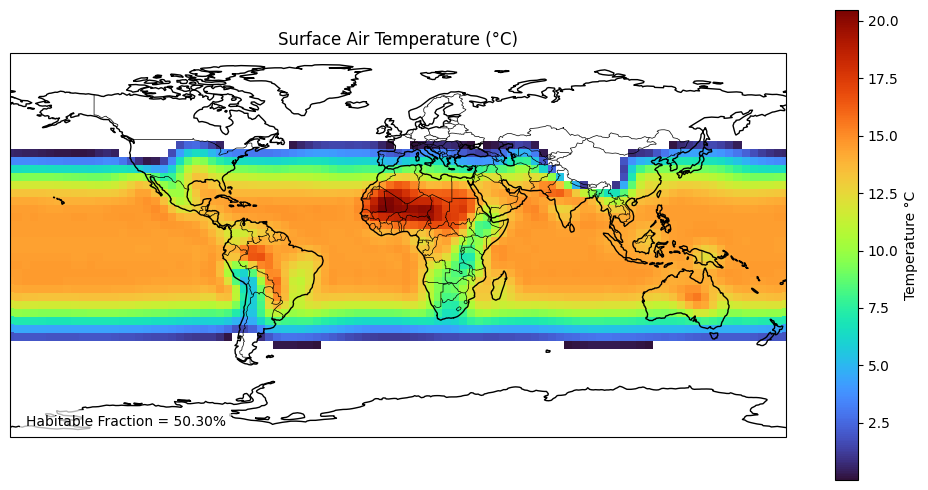

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Looking at global trends 
ds = xr.open_dataset("rotation_trials/output_rot_10.nc")

# Creating land mask from soil moisture variability (land only)
sm = ds["sm"].isel(soil_layer=0)
land = sm.std(dim="time") > 0

# Creating masked dataframes
da_sm = sm.mean(dim="time")
da_st = ds["st"].isel(soil_layer=0).mean(dim="time")
da_tsurf = ds["tsurf"].mean(dim="time")

# Creating habitability masks
hab_sm = (da_sm >= 0.1) & land
hab_st = (da_st >= 0) & (da_st <= 48) & land
hab_tsurf = (da_tsurf >= 0) & (da_tsurf <= 48)  # (NO land mask)

# Calculating habitability
hab_fraction_sm = hab_sm.sum().item() / land.sum().item() * 100
hab_fraction_st = hab_st.sum().item() / land.sum().item() * 100
hab_fraction_tsurf = hab_tsurf.mean().item() * 100

# Creating figures
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da_st.where(hab_st).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_st:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("rotation_trials/rot1.0_st.png")

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da_sm.where(hab_sm).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Soil Moisture"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Soil Moisture")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_sm:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("rotation_trials/rot1.0_sm.png")

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

da_tsurf.where(hab_tsurf).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Temperature °C"},
    cmap="turbo"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Surface Air Temperature (°C)")

ax.text(0.02, 0.02, f"Habitable Fraction = {hab_fraction_tsurf:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()
#plt.savefig("rotation_trials/rot1.0_tsurf.png")
